# RFM Segmentation + Logistic Regression

###  Import libraries

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

### Load Dataset 

In [87]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### Dataser inoformation 

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning 

In [91]:
# Fix TotalCharges datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

# Convert churn to numeric
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

###  Create Frequency Feature (Service Count)

In [93]:
services = [
'PhoneService','MultipleLines','InternetService','OnlineSecurity',
'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
df['Service_Count'] = df[services].apply(lambda x: (x=='Yes').sum(), axis=1)

### Create RFM Features

In [95]:
# Recency = tenure (lower tenure = higher churn risk)
df['Recency'] = df['tenure']

# Frequency = service usage
df['Frequency'] = df['Service_Count']

# Monetary = total revenue
df['Monetary'] = df['TotalCharges']

### RFM Scoring

In [97]:

df['Recency_Score'] = pd.qcut(df['Recency'], 5, labels=[5,4,3,2,1])
df['Frequency_Score'] = pd.qcut(df['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df['Monetary_Score'] = pd.qcut(df['Monetary'], 5, labels=[1,2,3,4,5])

df['RFM_Score'] = (
    df['Recency_Score'].astype(int) +
    df['Frequency_Score'].astype(int) +
    df['Monetary_Score'].astype(int))

###  Customer Segmentation

In [99]:
def rfm_segment(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 7:
        return "At-Risk Customers"

    elif score >= 4:
        return "Hibernating Customers"

    else:
        return "Lost Customers"

df['Segment'] = df['RFM_Score'].apply(rfm_segment)

print("\nCustomer Segments:")
print(df['Segment'].value_counts())


Customer Segments:
Segment
Loyal Customers          3195
At-Risk Customers        3059
Hibernating Customers     786
Champions                   3
Name: count, dtype: int64


###  Prepare Dataset for Machine learning Model 

In [101]:
features = [
'tenure',
'MonthlyCharges',
'TotalCharges',
'SeniorCitizen',
'Service_Count',
'RFM_Score'
]

X = df[features]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

###  Feature Scaling

In [103]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###  Logistic Regression Model

In [105]:
model = LogisticRegression(max_iter=1000)  #
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Model Prediction and Evaluation 

In [107]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]
# Model Evaluation
print("\nModel Accuracy:", round(accuracy_score(y_test, y_pred)*100,2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob),3))


Model Accuracy: 81.33 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


ROC-AUC Score: 0.849


### Confusion Matrix

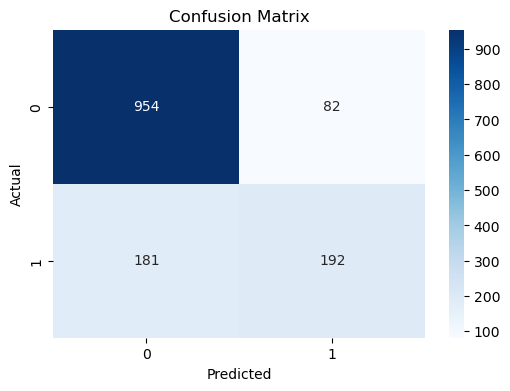

In [109]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###  Feature Importance

In [111]:
 importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:")
print(importance)


Feature Importance:
          Feature  Coefficient
1  MonthlyCharges     1.194710
2    TotalCharges     0.574306
5       RFM_Score     0.186940
3   SeniorCitizen     0.169141
4   Service_Count    -0.885267
0          tenure    -1.505357


###  Churn Probability Score

In [113]:
df['Churn_Risk'] = model.predict_proba(
    scaler.transform(X))[:,1]
print("\nTop High Risk Customers:")
print(
    df[['Segment','Churn_Risk','MonthlyCharges','tenure']]
    .sort_values(by='Churn_Risk', ascending=False)
    .head(10))


Top High Risk Customers:
                Segment  Churn_Risk  MonthlyCharges  tenure
2191  At-Risk Customers    0.812118           91.30       1
3467    Loyal Customers    0.803884           91.40       5
6552  At-Risk Customers    0.800365           79.75       2
5783  At-Risk Customers    0.799617           89.30       1
5825  At-Risk Customers    0.799241           70.30       1
6096  At-Risk Customers    0.798599           70.20       1
6165  At-Risk Customers    0.796703           70.65       4
5573  At-Risk Customers    0.796340           69.85       1
2441  At-Risk Customers    0.795814           81.50       2
6726  At-Risk Customers    0.795637           70.75       2


### Identify High Risk Customers

In [137]:
high_risk_customers = df[df['Churn_Risk'] > 0.7]
print("\nNumber of High Risk Customers:", len(high_risk_customers))
print(f"Potential Revenue at Risk from High-Risk: ${len(high_risk) * 64.76 * 12:,.0f}")


Number of High Risk Customers: 296
Potential Revenue at Risk from High-Risk: $230,028


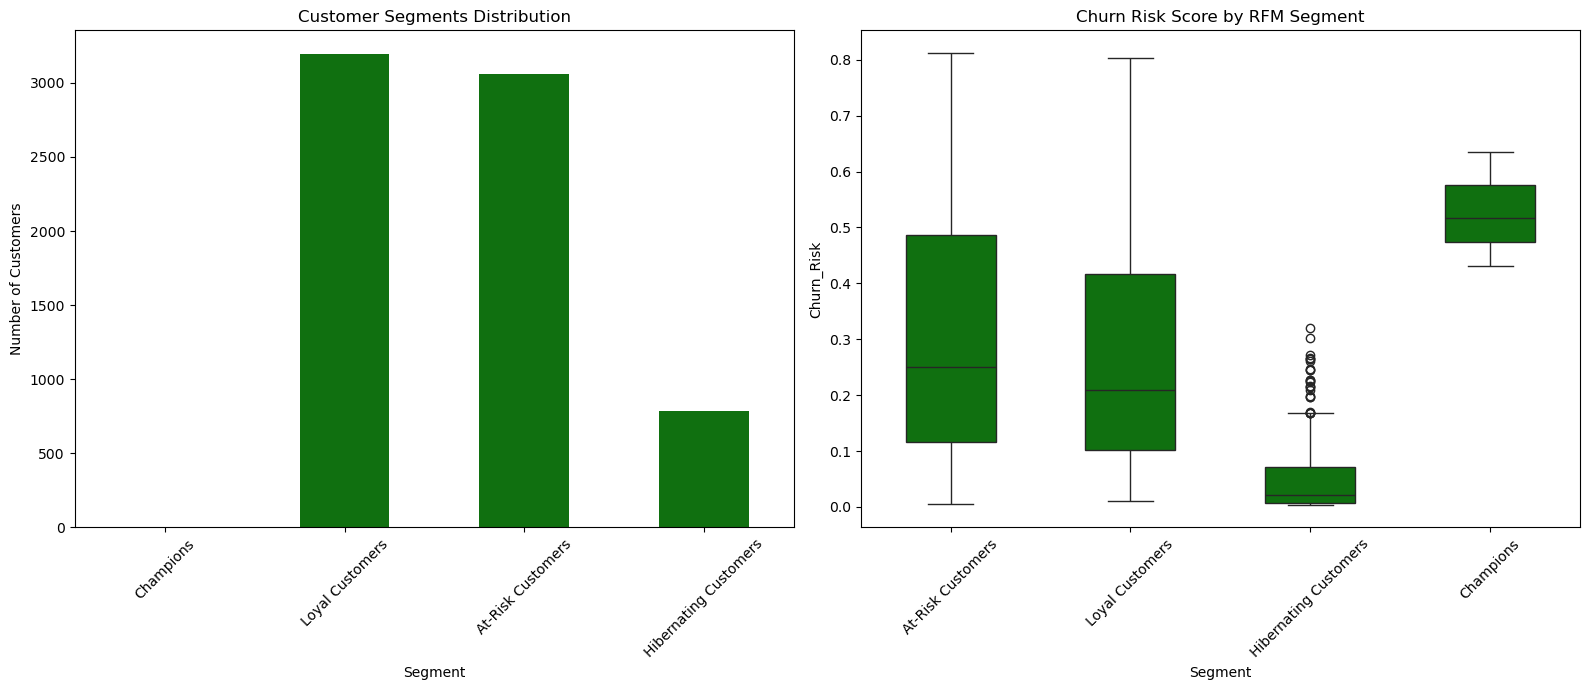

In [161]:
 # 1. Segment Distribution
plt.figure(figsize=(16,7))
plt.subplot(121)
sns.countplot(data=df, x='Segment', order=['Champions','Loyal Customers','At-Risk Customers','Hibernating Customers'],color='green',width=0.5)
plt.title('Customer Segments Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Customers')

# 2. Churn Risk by Segment (Boxplot)
plt.subplot(122)
sns.boxplot(data=df, x='Segment', y='Churn_Risk',color='green',width=0.5)
plt.title('Churn Risk Score by RFM Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()